## Lectura de archivos Indices

Se fusionará entre los distintos tipos de archivos

In [1]:
import pandas as pd

cols = [
    "year","month","day","days","days_m","BSR","dB",
    "Kp1","Kp2","Kp3","Kp4","Kp5","Kp6","Kp7","Kp8",
    "ap1","ap2","ap3","ap4","ap5","ap6","ap7","ap8",
    "Ap","SN","F10.7obs","F10.7adj","D"
]

df_f107 = pd.read_csv(
    "./dataset/Kp_ap_Ap_SN_F107_since_1932.txt",
    comment="#",
    sep=r"\s+",      # <-- reemplaza delim_whitespace=True
    names=cols,
    engine="python"  # opcional, pero recomendado con regex
)
df_f107["fecha[UTC]"] = pd.to_datetime(
    df_f107[["year", "month", "day"]]
)
df_f107 = (
    df_f107
    .set_index("fecha[UTC]")
    .resample("5min")
    .ffill()
    .reset_index()
)

df_f107 = df_f107[["fecha[UTC]","F10.7obs","F10.7adj"]]

print(df_f107.head())

           fecha[UTC]  F10.7obs  F10.7adj
0 1932-01-01 00:00:00      -1.0      -1.0
1 1932-01-01 00:05:00      -1.0      -1.0
2 1932-01-01 00:10:00      -1.0      -1.0
3 1932-01-01 00:15:00      -1.0      -1.0
4 1932-01-01 00:20:00      -1.0      -1.0


In [2]:
cols = ["year", "month", "day", "hour_start", "hour_mid",
        "days", "days_m", "Kp", "ap", "D"]


df_ap = pd.read_csv(
    "./dataset/Kp_ap_since_1932.txt",
    comment="#",
    sep=r"\s+",      # <-- reemplaza delim_whitespace=True
    names=cols,
    engine="python"  # opcional, pero recomendado con regex
)
 

df_ap = df_ap.rename(columns={"hour_start": "hour"})
df_ap["hour"] = df_ap["hour"].astype(int)


df_ap["fecha[UTC]"] = pd.to_datetime(
    df_ap[["year", "month", "day", "hour"]]
)
 
df_ap = df_ap[["fecha[UTC]","ap","Kp"]]
df_ap = (
    df_ap
    .set_index("fecha[UTC]")
    .resample("5min")
    .ffill()
    .reset_index()
)

df_ap.head()

,fecha[UTC],ap,Kp
0,1932-01-01 00:00:00,18,3.333
1,1932-01-01 00:05:00,18,3.333
2,1932-01-01 00:10:00,18,3.333
3,1932-01-01 00:15:00,18,3.333
4,1932-01-01 00:20:00,18,3.333


In [18]:
 
df_flux = pd.read_parquet("./dataset/flux_res_5m.parquet",
                         )
df_flux = (
    df_flux
    .set_index("date[UTC]")
    .resample("5min")
    .ffill()
    .reset_index()
)
df_flux = df_flux.rename(columns={
    "date[UTC]": "fecha[UTC]",
})


df_flux

,fecha[UTC],flux
0,2010-01-01 00:00:00,283.60
1,2010-01-01 00:05:00,284.14
2,2010-01-01 00:10:00,284.86
3,2010-01-01 00:15:00,284.50
4,2010-01-01 00:20:00,282.94
...,...,...
1729435,2026-06-10 23:35:00,393.56
1729436,2026-06-10 23:40:00,395.52
1729437,2026-06-10 23:45:00,393.48
1729438,2026-06-10 23:50:00,393.26


In [21]:
### leemos datos parquet para symH 
df_symh = pd.read_parquet("./dataset/symH_res_5m.parquet",
                         )
df_symh = (
    df_symh
    .set_index("date[UTC]")
    .resample("5min")
    .ffill()
    .reset_index()
)

df_symh = df_symh.rename(columns={
    "date[UTC]": "fecha[UTC]",
})
df_symh


,fecha[UTC],symH
0,1988-01-01 00:00:00,-6.8
1,1988-01-01 00:05:00,-6.2
2,1988-01-01 00:10:00,-6.2
3,1988-01-01 00:15:00,-6.4
4,1988-01-01 00:20:00,-7.0
...,...,...
4014427,2026-02-28 23:35:00,4.2
4014428,2026-02-28 23:40:00,4.2
4014429,2026-02-28 23:45:00,4.0
4014430,2026-02-28 23:50:00,4.0


In [50]:
df_Bz = pd.read_parquet("./dataset/Bz_res_5m.parquet",
                         )
df_Bz = (
    df_Bz
    .set_index("date[UTC]")
    .resample("5min")
    .ffill()
    .reset_index()
)
df_Bz = df_Bz.rename(columns={
    "date[UTC]": "fecha[UTC]",
})
df_Bz


,fecha[UTC],Bz
0,1988-01-01 00:00:00,0.000
1,1988-01-01 00:05:00,0.000
2,1988-01-01 00:10:00,0.000
3,1988-01-01 00:15:00,0.000
4,1988-01-01 00:20:00,0.000
...,...,...
3997723,2026-01-01 23:35:00,4.400
3997724,2026-01-01 23:40:00,3.592
3997725,2026-01-01 23:45:00,3.362
3997726,2026-01-01 23:50:00,5.920


In [51]:
total = pd.merge(df_f107, df_ap, on="fecha[UTC]", how="left")
total = pd.merge(total, df_flux, on="fecha[UTC]", how="left")
total = pd.merge(total,df_symh, on="fecha[UTC]", how="left")
total = pd.merge(total,df_Bz,on='fecha[UTC]',how='left')
#total = total.dropna()

total

,fecha[UTC],F10.7obs,F10.7adj,ap,Kp,flux,symH,Bz
0,1932-01-01 00:00:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN
1,1932-01-01 00:05:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN
2,1932-01-01 00:10:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN
3,1932-01-01 00:15:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN
4,1932-01-01 00:20:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
9938012,2026-06-22 23:40:00,121.5,125.5,NaN,NaN,NaN,NaN,NaN
9938013,2026-06-22 23:45:00,121.5,125.5,NaN,NaN,NaN,NaN,NaN
9938014,2026-06-22 23:50:00,121.5,125.5,NaN,NaN,NaN,NaN,NaN
9938015,2026-06-22 23:55:00,121.5,125.5,NaN,NaN,NaN,NaN,NaN


In [25]:
total[["F10.7obs", "F10.7adj", "ap", "Kp", "flux", "symH", "Bz"]].describe().T

,count,mean,std,min,25%,50%,75%,max
F10.7obs,1540744.0,111.440311,42.799518,-1.000000,75.200,102.200,137.600000,938.600
F10.7adj,1540744.0,111.399977,42.623116,-1.000000,75.500,102.800,137.400000,924.400
ap,1540744.0,9.110310,13.324764,0.000000,3.000,5.000,9.000000,400.000
Kp,1540744.0,1.712361,1.280833,0.000000,0.667,1.333,2.333000,9.000
flux,1540744.0,420.106623,93.929481,238.266667,350.100,399.400,470.466667,1079.000
symH,1540744.0,-11.031853,17.890234,-497.000000,-17.800,-8.000,-0.800000,136.200
Bz,1540744.0,-0.020892,3.141678,-54.516000,-1.616,-0.016,1.572000,37.246


In [52]:
## pasar de UTC a LT
total["fecha_LT"] = (
    pd.to_datetime(total["fecha[UTC]"], utc=True)
    .dt.tz_convert("America/Lima")
)
total

,fecha[UTC],F10.7obs,F10.7adj,ap,Kp,flux,symH,Bz,fecha_LT
0,1932-01-01 00:00:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN,1931-12-31 19:00:00-05:00
1,1932-01-01 00:05:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN,1931-12-31 19:05:00-05:00
2,1932-01-01 00:10:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN,1931-12-31 19:10:00-05:00
3,1932-01-01 00:15:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN,1931-12-31 19:15:00-05:00
4,1932-01-01 00:20:00,-1.0,-1.0,18.0,3.333,NaN,NaN,NaN,1931-12-31 19:20:00-05:00
...,...,...,...,...,...,...,...,...,...
9938012,2026-06-22 23:40:00,121.5,125.5,NaN,NaN,NaN,NaN,NaN,2026-06-22 18:40:00-05:00
9938013,2026-06-22 23:45:00,121.5,125.5,NaN,NaN,NaN,NaN,NaN,2026-06-22 18:45:00-05:00
9938014,2026-06-22 23:50:00,121.5,125.5,NaN,NaN,NaN,NaN,NaN,2026-06-22 18:50:00-05:00
9938015,2026-06-22 23:55:00,121.5,125.5,NaN,NaN,NaN,NaN,NaN,2026-06-22 18:55:00-05:00


In [53]:
fecha = "2022-10-1"

fecha_init = fecha + " 06:00:00.0"
fecha_fin = fecha + " 17:59:59.0"

df = total.loc[total["fecha_LT"].between(fecha_init, fecha_fin)]

df

,fecha[UTC],F10.7obs,F10.7adj,ap,Kp,flux,symH,Bz,fecha_LT
9546180,2022-10-01 11:00:00,147.9,148.3,2.0,0.333,NaN,-10.0,0.000,2022-10-01 06:00:00-05:00
9546181,2022-10-01 11:05:00,147.9,148.3,2.0,0.333,NaN,-10.8,0.000,2022-10-01 06:05:00-05:00
9546182,2022-10-01 11:10:00,147.9,148.3,2.0,0.333,NaN,-11.0,0.000,2022-10-01 06:10:00-05:00
9546183,2022-10-01 11:15:00,147.9,148.3,2.0,0.333,NaN,-11.0,0.000,2022-10-01 06:15:00-05:00
9546184,2022-10-01 11:20:00,147.9,148.3,2.0,0.333,NaN,-11.0,0.000,2022-10-01 06:20:00-05:00
...,...,...,...,...,...,...,...,...,...
9546319,2022-10-01 22:35:00,147.9,148.3,3.0,0.667,444.775000,-0.2,1.560,2022-10-01 17:35:00-05:00
9546320,2022-10-01 22:40:00,147.9,148.3,3.0,0.667,431.933333,-1.0,4.150,2022-10-01 17:40:00-05:00
9546321,2022-10-01 22:45:00,147.9,148.3,3.0,0.667,427.940000,-1.0,5.970,2022-10-01 17:45:00-05:00
9546322,2022-10-01 22:50:00,147.9,148.3,3.0,0.667,428.100000,-1.0,4.844,2022-10-01 17:50:00-05:00


In [37]:
df.set_index("fecha_LT").resample("5min").ffill().reset_index()

,fecha_LT,fecha[UTC],F10.7obs,F10.7adj,ap,Kp,flux,symH,Bz
0,2024-05-14 06:00:00-05:00,2024-05-14 11:00:00,219.8,224.6,9.0,2.333,531.94,-55.2,-1.064
1,2024-05-14 06:05:00-05:00,2024-05-14 11:05:00,219.8,224.6,9.0,2.333,530.40,-55.8,0.130
2,2024-05-14 06:10:00-05:00,2024-05-14 11:10:00,219.8,224.6,9.0,2.333,527.40,-56.0,-0.688
3,2024-05-14 06:15:00-05:00,2024-05-14 11:15:00,219.8,224.6,9.0,2.333,528.52,-57.0,-0.452
4,2024-05-14 06:20:00-05:00,2024-05-14 11:20:00,219.8,224.6,9.0,2.333,523.32,-59.2,-0.988
...,...,...,...,...,...,...,...,...,...
139,2024-05-14 17:35:00-05:00,2024-05-14 22:35:00,219.8,224.6,3.0,0.667,510.10,-43.6,0.696
140,2024-05-14 17:40:00-05:00,2024-05-14 22:40:00,219.8,224.6,3.0,0.667,497.30,-43.6,0.566
141,2024-05-14 17:45:00-05:00,2024-05-14 22:45:00,219.8,224.6,3.0,0.667,507.60,-44.8,0.968
142,2024-05-14 17:50:00-05:00,2024-05-14 22:50:00,219.8,224.6,3.0,0.667,502.44,-45.0,1.118


In [64]:
def get_index_data(df,fecha_init,fecha_fin):
    
    time_grid = pd.date_range(
        start=fecha_init,
        end=fecha_fin,
        freq="5min"
    )
    df = (
        df.set_index("fecha_LT")
          .reindex(
              time_grid,
              method="nearest",
              tolerance=pd.Timedelta("30min")
          )
          .rename_axis("fecha_LT")
          .reset_index()
    )
    return df 

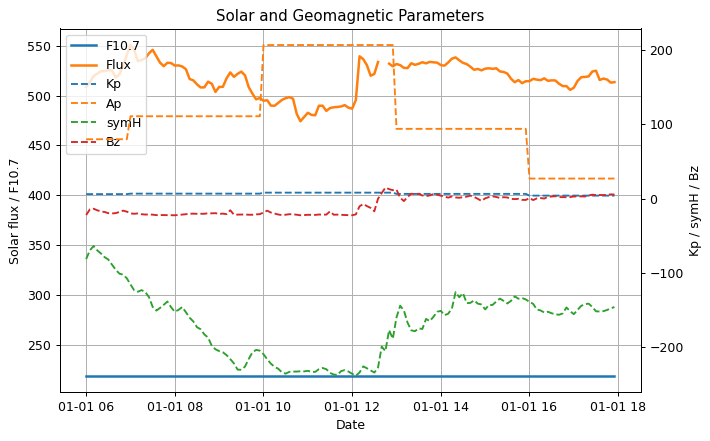

In [71]:
import matplotlib.pyplot as plt

fecha = "2025-1-1"

fecha_init = pd.Timestamp(fecha + " 06:00:00.0", tz="America/Lima")
fecha_fin  = pd.Timestamp(fecha + " 17:59:59.0", tz="America/Lima")

df = get_index_data(total,fecha_init,fecha_fin)

fig = plt.figure(figsize=(8, 5), dpi=90)

f107 = df["F10.7obs"].values
kp= df["Kp"].values
ap = df["ap"].values
flux = df["flux"].values
symH = df["symH"].values
Bz = df["Bz"].values

time = df["fecha_LT"]  # si tienes fecha como índice

# Primer eje
ax = fig.add_subplot(111)

ax.plot(time, f107, label="F10.7", linewidth=2)
ax.plot(time, flux, label="Flux", linewidth=2)

ax.set_xlabel("Date")
ax.set_ylabel("Solar flux / F10.7")
ax.grid(True)

# Segundo eje
ax2 = ax.twinx()

ax2.plot(time, kp, label="Kp", linestyle="--")
ax2.plot(time, ap, label="Ap", linestyle="--")
ax2.plot(time, symH, label="symH", linestyle="--")
ax2.plot(time, Bz, label="Bz", linestyle="--")

ax2.set_ylabel("Kp / symH / Bz")

# Combinar leyendas de ambos ejes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines + lines2,
    labels + labels2,
    loc="upper left"
)

plt.title("Solar and Geomagnetic Parameters")
plt.tight_layout()
plt.show()

In [75]:
total.to_parquet("./dataset/indexes.parquet")